# Feature Engineering Impact Analysis

This notebook isolates the effect of **domain-driven feature engineering** on model performance. For each of the four models in our ensemble (Logistic Regression, Random Forest, SVC, CatBoost), we compare:

| Pipeline | Feature Engineer | Encoding | Estimator |
|----------|-----------------|----------|-----------|
| **Baseline** | `BaselineEngineer` (drop 3 cols + `no_checking` flag) | Generic `OneHotEncoder` + `StandardScaler` | Default hyperparameters |
| **Engineered** | `FeatureEngineer` (ratios, logs, bins, category merging) | Config-driven per-model encoders (WOE, Target, Ordinal, etc.) | Default hyperparameters |

**Design choices:**
- No SMOTE, no hyperparameter tuning, no cost-weighting — we only vary the feature engineering
- Default estimator hyperparameters throughout, so any performance difference is attributable to feature engineering alone
- Side-by-side learning curves show overfitting/underfitting diagnostics for each variant

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Ensure the src package is importable
sys.path.insert(0, str(Path.cwd().parent / "src"))

from credit_risk_model.config.core import load_config, DATA_DIR
from credit_risk_model.processing.features import FeatureEngineer, BaselineEngineer
from credit_risk_model.processing.preprocessors import build_column_transformer, build_catboost_input
from credit_risk_model.processing.catboost_wrapper import CatBoostSklearnWrapper

cfg = load_config()
print(f"Models configured: {list(cfg.models.keys())}")
print(f"Data dir: {DATA_DIR}")

Models configured: ['lrc', 'rfc', 'svc', 'cat']
Data dir: /Users/fotisn/code/repos/credit_risk/credit-risk-project/data/processed


## Load Data & Train/Validation Split

In [2]:
df = pd.read_csv(DATA_DIR / cfg.training_data_file)
X = df.drop(columns=[cfg.target])
y = df[cfg.target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=cfg.val_size, stratify=y, random_state=cfg.random_state
)
print(f"Training: {X_train.shape[0]} samples | Validation: {X_val.shape[0]} samples")
print(f"Class distribution (train): {y_train.value_counts().to_dict()}")

Training: 691 samples | Validation: 150 samples
Class distribution (train): {1: 488, 0: 203}


## Helper Functions

In [3]:
def build_baseline_pipeline(estimator, is_catboost=False):
    """Build a baseline pipeline: BaselineEngineer → generic OneHot+Scale → estimator.
    
    For CatBoost, we skip encoding and let it handle categoricals natively.
    """
    fe = BaselineEngineer()
    
    if is_catboost:
        # After BaselineEngineer, identify categorical vs numeric columns
        # We'll use a simple approach: OneHot everything + Scale numerics
        # But CatBoost works better with native categoricals, so we pass through
        X_sample = fe.fit_transform(X_train.head(5))
        cat_cols = X_sample.select_dtypes(include=["object", "category"]).columns.tolist()
        num_cols = X_sample.select_dtypes(include=["number"]).columns.tolist()
        cat_indices = list(range(len(num_cols), len(num_cols) + len(cat_cols)))
        
        preprocessor = ColumnTransformer(
            transformers=[("select", "passthrough", num_cols + cat_cols)],
            remainder="drop",
        )
        # Update the wrapper's cat_features
        wrapper = CatBoostSklearnWrapper(
            cat_features=cat_indices, verbose=0, iterations=300
        )
        return Pipeline([("feature_engineer", fe), ("preprocessor", preprocessor), ("model", wrapper)])
    
    # For sklearn models: detect column types after BaselineEngineer
    X_sample = fe.fit_transform(X_train.head(5))
    cat_cols = X_sample.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = X_sample.select_dtypes(include=["number"]).columns.tolist()
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
            ("num", StandardScaler(), num_cols),
        ],
        remainder="drop",
    )
    return Pipeline([("feature_engineer", fe), ("preprocessor", preprocessor), ("model", estimator)])


def build_engineered_pipeline(estimator, model_key, is_catboost=False):
    """Build an engineered pipeline using the project's config-driven encoders."""
    model_cfg = cfg.models[model_key]
    
    if is_catboost:
        fe = FeatureEngineer()
        selector, cat_indices = build_catboost_input(model_cfg)
        wrapper = CatBoostSklearnWrapper(
            cat_features=cat_indices, verbose=0, iterations=300
        )
        return Pipeline([("feature_engineer", fe), ("preprocessor", selector), ("model", wrapper)])
    
    fe = FeatureEngineer(
        duplicate_checking=model_cfg.duplicate_checking,
        duplicate_amount=model_cfg.duplicate_amount,
    )
    preprocessor = build_column_transformer(model_cfg)
    return Pipeline([("feature_engineer", fe), ("preprocessor", preprocessor), ("model", estimator)])


def evaluate_model(pipeline, X_tr, y_tr, X_v, y_v):
    """Fit pipeline on training data and return validation metrics."""
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_v)
    
    # For AUC, try predict_proba; fall back to decision_function
    try:
        y_proba = pipeline.predict_proba(X_v)[:, 1]
        auc = roc_auc_score(y_v, y_proba)
    except AttributeError:
        try:
            y_scores = pipeline.decision_function(X_v)
            auc = roc_auc_score(y_v, y_scores)
        except AttributeError:
            auc = np.nan
    
    return {
        "Accuracy": accuracy_score(y_v, y_pred),
        "Precision": precision_score(y_v, y_pred),
        "Recall": recall_score(y_v, y_pred),
        "F1": f1_score(y_v, y_pred),
        "ROC AUC": auc,
    }


def plot_side_by_side_learning_curves(pipe_base, pipe_eng, X_tr, y_tr, model_name, cv=5):
    """Plot baseline vs. engineered learning curves side by side."""
    train_sizes = np.linspace(0.1, 1.0, 8)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    
    for ax, pipe, label in zip(axes, [pipe_base, pipe_eng], ["Baseline", "Engineered"]):
        sizes, train_scores, val_scores = learning_curve(
            pipe, X_tr, y_tr, train_sizes=train_sizes, cv=cv,
            scoring="roc_auc", n_jobs=-1, shuffle=True, random_state=cfg.random_state,
        )
        t_mean, t_std = train_scores.mean(axis=1), train_scores.std(axis=1)
        v_mean, v_std = val_scores.mean(axis=1), val_scores.std(axis=1)
        
        ax.plot(sizes, t_mean, "o-", color="steelblue", label="Training")
        ax.fill_between(sizes, t_mean - t_std, t_mean + t_std, alpha=0.15, color="steelblue")
        ax.plot(sizes, v_mean, "o-", color="darkorange", label="Cross-validation")
        ax.fill_between(sizes, v_mean - v_std, v_mean + v_std, alpha=0.15, color="darkorange")
        
        gap = t_mean[-1] - v_mean[-1]
        ax.set_title(f"{model_name} — {label}\nFinal CV: {v_mean[-1]:.3f} | Gap: {gap:.3f}")
        ax.set_xlabel("Training examples")
        ax.set_ylabel("ROC AUC")
        ax.legend(loc="lower right")
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def compare_metrics(base_metrics, eng_metrics, model_name):
    """Display a comparison table and highlight improvements."""
    df = pd.DataFrame({"Baseline": base_metrics, "Engineered": eng_metrics})
    df["Δ (Eng - Base)"] = df["Engineered"] - df["Baseline"]
    df["Δ %"] = (df["Δ (Eng - Base)"] / df["Baseline"] * 100).round(1)
    print(f"\n{'='*60}")
    print(f"  {model_name} — Metric Comparison")
    print(f"{'='*60}")
    display(df.style.format("{:.4f}", subset=["Baseline", "Engineered", "Δ (Eng - Base)"])
                     .format("{:.1f}%", subset=["Δ %"])
                     .map(lambda v: "color: green" if v > 0 else "color: red" if v < 0 else "", subset=["Δ (Eng - Base)"]))
    return df


def plot_permutation_importance(pipe, X_v, y_v, model_name, variant="Engineered", top_n=15):
    """Plot permutation importance for a fitted pipeline.
    
    Uses the full pipeline so importances reflect the combined effect of
    feature engineering + encoding + model. We permute the *raw* input
    columns (before FeatureEngineer), so the importances are interpretable
    in terms of the original dataset features.
    """
    from sklearn.inspection import permutation_importance
    
    result = permutation_importance(
        pipe, X_v, y_v, n_repeats=10, random_state=cfg.random_state,
        scoring="roc_auc", n_jobs=-1,
    )
    
    # Build a DataFrame of importances using the raw column names
    feat_names = X_v.columns.tolist()
    perm_df = pd.DataFrame({
        "Feature": feat_names,
        "Importance": result.importances_mean,
        "Std": result.importances_std,
    }).sort_values("Importance", ascending=False).head(top_n)
    
    fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.35)))
    bars = ax.barh(
        perm_df["Feature"][::-1], perm_df["Importance"][::-1],
        xerr=perm_df["Std"][::-1], color="steelblue", edgecolor="gray", alpha=0.85,
    )
    ax.set_xlabel("Mean decrease in ROC AUC")
    ax.set_title(f"{model_name} ({variant}) — Permutation Importance (top {top_n})")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return perm_df


def _get_transformed_feature_names(pipe):
    """Extract feature names from the fitted ColumnTransformer inside a pipeline."""
    ct = pipe.named_steps["preprocessor"]
    names = []
    for name, trans, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(trans, "get_feature_names_out"):
            names.extend(trans.get_feature_names_out(cols))
        elif trans == "passthrough":
            names.extend(cols if isinstance(cols, list) else [cols])
        else:
            # Encoders like WOE/Target/Count output same number of cols
            names.extend(cols if isinstance(cols, list) else [cols])
    return names


def plot_post_encoding_importance(pipe, X_v, y_v, model_name, variant="Engineered", top_n=20):
    """Plot permutation importance on the *post-encoding* features.
    
    This shows which encoded/transformed columns the model actually relies on,
    after FeatureEngineer + ColumnTransformer have run. Unlike the raw-column
    version, this reveals the importance of derived features like `credit_log`,
    `monthly_burden_log`, one-hot dummies, WOE-encoded columns, etc.
    """
    from sklearn.inspection import permutation_importance
    
    # Transform X through feature_engineer + preprocessor to get encoded data
    fe = pipe.named_steps["feature_engineer"]
    ct = pipe.named_steps["preprocessor"]
    X_transformed = ct.transform(fe.transform(X_v))
    
    # Convert to DataFrame if sparse
    if hasattr(X_transformed, "toarray"):
        X_transformed = X_transformed.toarray()
    
    feat_names = _get_transformed_feature_names(pipe)
    
    # If names don't match columns (can happen with complex encoders), fall back
    if len(feat_names) != X_transformed.shape[1]:
        feat_names = [f"feature_{i}" for i in range(X_transformed.shape[1])]
    
    X_enc = pd.DataFrame(X_transformed, columns=feat_names)
    
    # Run permutation importance on just the model step
    model = pipe.named_steps["model"]
    result = permutation_importance(
        model, X_enc, y_v, n_repeats=10, random_state=cfg.random_state,
        scoring="roc_auc", n_jobs=-1,
    )
    
    perm_df = pd.DataFrame({
        "Feature": feat_names,
        "Importance": result.importances_mean,
        "Std": result.importances_std,
    }).sort_values("Importance", ascending=False).head(top_n)
    
    fig, ax = plt.subplots(figsize=(9, max(4, top_n * 0.35)))
    ax.barh(
        perm_df["Feature"][::-1], perm_df["Importance"][::-1],
        xerr=perm_df["Std"][::-1], color="darkorange", edgecolor="gray", alpha=0.85,
    )
    ax.set_xlabel("Mean decrease in ROC AUC")
    ax.set_title(f"{model_name} ({variant}) — Post-Encoding Feature Importance (top {top_n})")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return perm_df

In [4]:
# Store results for the final summary
all_results = {}

---
## 1. Logistic Regression (LRC)

**Engineered pipeline uses:** WOE encoding for checking/purpose/employment/property/housing, one-hot for history/savings/residence/personal_status/age_group/job/foreign_worker, count encoding for installment_rate/other_plans, log-transformed numerics, and the `no_checking` passthrough flag.

In [5]:
# Logistic Regression — Baseline vs Engineered
lrc_base_pipe = build_baseline_pipeline(LogisticRegression(max_iter=2000, random_state=cfg.random_state))
lrc_eng_pipe = build_engineered_pipeline(LogisticRegression(max_iter=2000, random_state=cfg.random_state), "lrc")

lrc_base_metrics = evaluate_model(lrc_base_pipe, X_train, y_train, X_val, y_val)
lrc_eng_metrics = evaluate_model(lrc_eng_pipe, X_train, y_train, X_val, y_val)

all_results["LRC"] = compare_metrics(lrc_base_metrics, lrc_eng_metrics, "Logistic Regression")


  Logistic Regression — Metric Comparison


,Baseline,Engineered,Δ (Eng - Base),Δ %
Accuracy,0.7467,0.7467,0.0000,0.0%
Precision,0.7931,0.8036,0.0105,1.3%
Recall,0.8679,0.8491,-0.0189,-2.2%
F1,0.8288,0.8257,-0.0031,-0.4%
ROC AUC,0.7807,0.7811,0.0004,0.1%


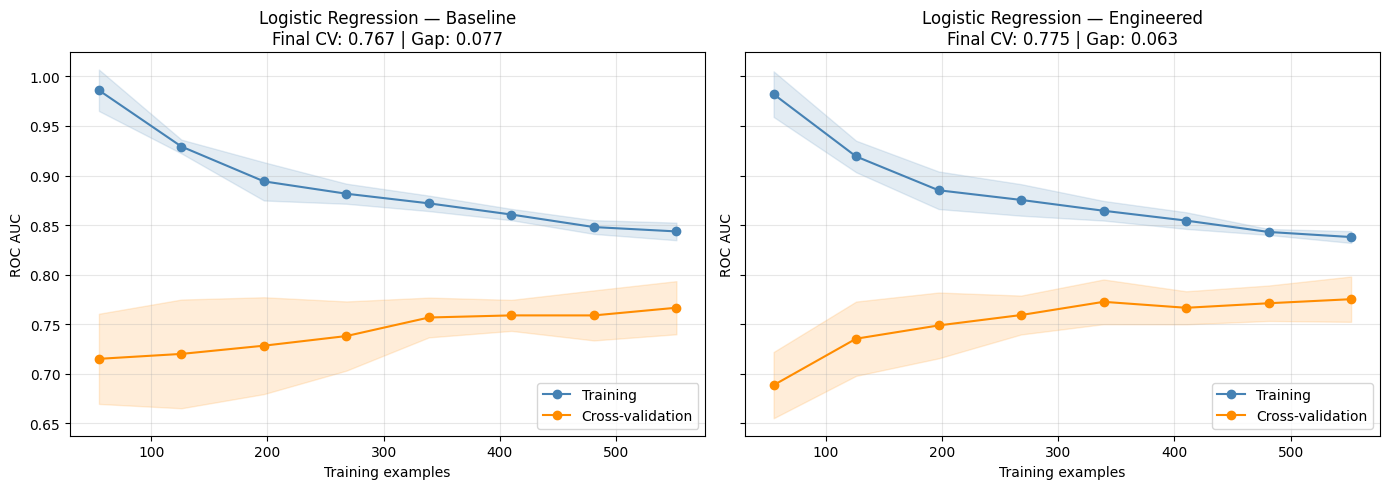

In [6]:
plot_side_by_side_learning_curves(lrc_base_pipe, lrc_eng_pipe, X_train, y_train, "Logistic Regression")

In [7]:
# DEBUG: Inspect columns produced by BaselineEngineer vs FeatureEngineer
baseline_fe = BaselineEngineer()
engineered_fe = FeatureEngineer(duplicate_checking=True, duplicate_amount=True)

X_baseline = baseline_fe.fit_transform(X_train)
X_engineered = engineered_fe.fit_transform(X_train)

print(f"{'='*60}")
print(f"  BaselineEngineer output: {X_baseline.shape[1]} columns")
print(f"{'='*60}")
print(f"Columns: {X_baseline.columns.tolist()}\n")
print(f"Dtypes:\n{X_baseline.dtypes.value_counts()}\n")

print(f"{'='*60}")
print(f"  FeatureEngineer output: {X_engineered.shape[1]} columns")
print(f"{'='*60}")
print(f"Columns: {X_engineered.columns.tolist()}\n")
print(f"Dtypes:\n{X_engineered.dtypes.value_counts()}\n")

# Show what's new in the engineered version
base_set = set(X_baseline.columns)
eng_set = set(X_engineered.columns)
print(f"Columns ADDED by FeatureEngineer: {sorted(eng_set - base_set)}")
print(f"Columns REMOVED by FeatureEngineer: {sorted(base_set - eng_set)}")

  BaselineEngineer output: 18 columns
Columns: ['checking_account_status', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account_bonds', 'present_employment_since', 'installment_rate_pct_of_disp_income', 'personal_status_sex', 'present_residence_since', 'property', 'age_years', 'other_installment_plans', 'housing', 'existing_credits_count', 'job', 'foreign_worker', 'no_checking']

Dtypes:
object    11
int64      7
Name: count, dtype: int64

  FeatureEngineer output: 30 columns
Columns: ['checking_account_status', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account_bonds', 'present_employment_since', 'installment_rate_pct_of_disp_income', 'personal_status_sex', 'present_residence_since', 'property', 'age_years', 'other_installment_plans', 'housing', 'existing_credits_count', 'job', 'foreign_worker', 'no_checking', 'monthly_burden', 'duration_to_age_ratio', 'duration_to_age_ratio_sqrt', 'duration_squared', 'credit_amount_squared',

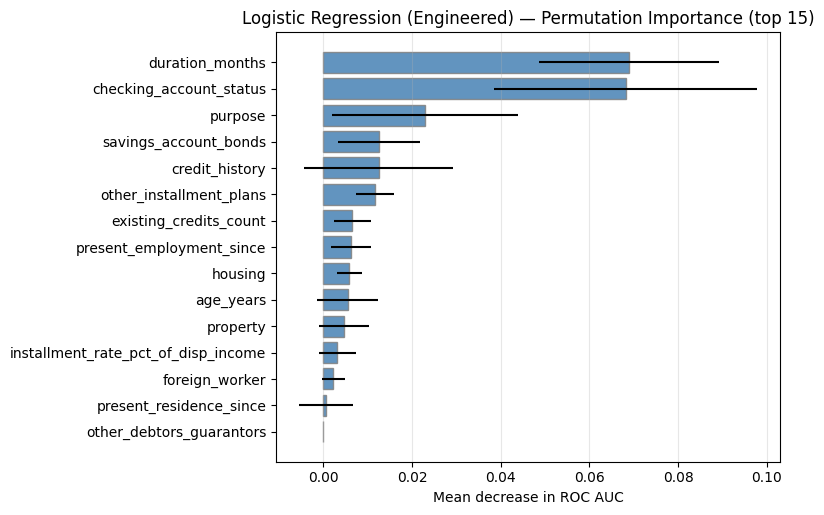

/Users/fotisn/code/repos/credit_risk/credit-risk-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/fotisn/code/repos/credit_risk/credit-risk-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/fotisn/code/repos/credit_risk/credit-risk-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/fotisn/code/repos/credit_risk/credit-risk-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/fotisn/code/repos/credit_risk/credit-risk-project/.venv/lib/p

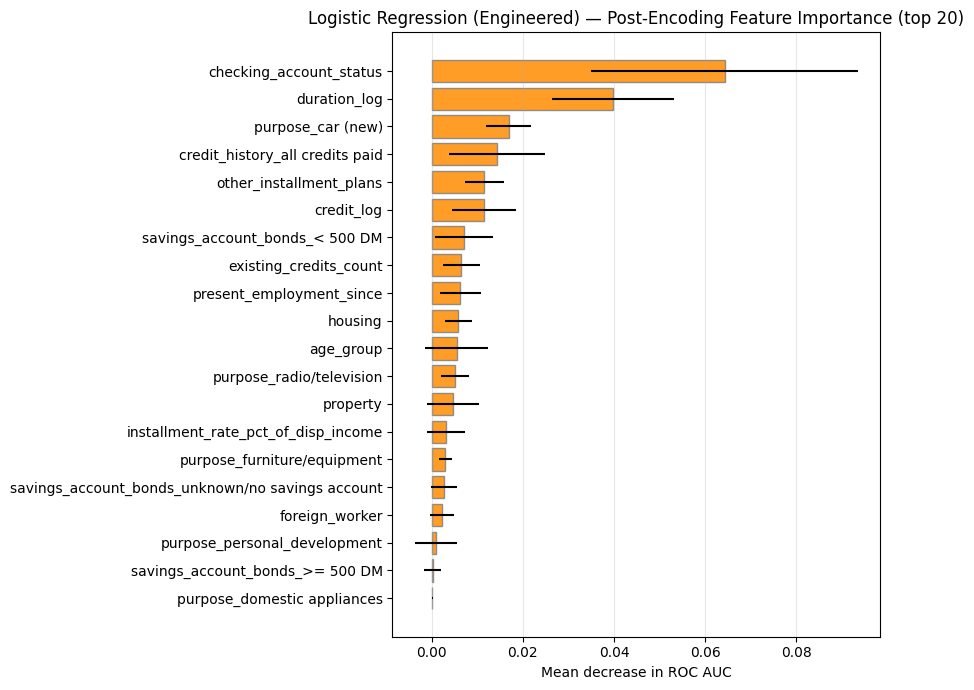

,Feature,Importance,Std
19,checking_account_status,0.064237,0.029222
29,duration_log,0.039751,0.013420
12,purpose_car (new),0.016874,0.004918
0,credit_history_all credits paid,0.014258,0.010503
28,other_installment_plans,0.011557,0.004241
30,credit_log,0.011514,0.007061
4,savings_account_bonds_< 500 DM,0.007118,0.006436
31,existing_credits_count,0.006518,0.004096
20,present_employment_since,0.006282,0.004475
22,housing,0.005853,0.002888


In [8]:
# LRC — Permutation Importance (raw input columns → total downstream effect)
plot_permutation_importance(lrc_eng_pipe, X_val, y_val, "Logistic Regression")

plot_post_encoding_importance(lrc_eng_pipe, X_val, y_val, "Logistic Regression")
# LRC — Post-Encoding Importance (actual features the model sees)

---
## 2. Random Forest (RFC)

**Engineered pipeline uses:** One-hot for 8 categoricals, ordinal encoding for installment_rate/job/personal_status_2/checking/age_group (RFC benefits from ordinal encoding of naturally ordered features), target encoding for property, log credit amount + duration-to-age ratio as scaled numerics, and 4 passthrough columns. The `duplicate_checking` flag creates `checking_2` and `personal_status_2` duplicate columns.

In [9]:
# Random Forest — Baseline vs Engineered
rfc_base_pipe = build_baseline_pipeline(RandomForestClassifier(n_estimators=100, random_state=cfg.random_state))
rfc_eng_pipe = build_engineered_pipeline(RandomForestClassifier(n_estimators=100, random_state=cfg.random_state), "rfc")

rfc_base_metrics = evaluate_model(rfc_base_pipe, X_train, y_train, X_val, y_val)
rfc_eng_metrics = evaluate_model(rfc_eng_pipe, X_train, y_train, X_val, y_val)

all_results["RFC"] = compare_metrics(rfc_base_metrics, rfc_eng_metrics, "Random Forest")


  Random Forest — Metric Comparison


,Baseline,Engineered,Δ (Eng - Base),Δ %
Accuracy,0.7533,0.7667,0.0133,1.8%
Precision,0.8053,0.8034,-0.0019,-0.2%
Recall,0.8585,0.8868,0.0283,3.3%
F1,0.8311,0.8430,0.0120,1.4%
ROC AUC,0.7834,0.8018,0.0183,2.3%


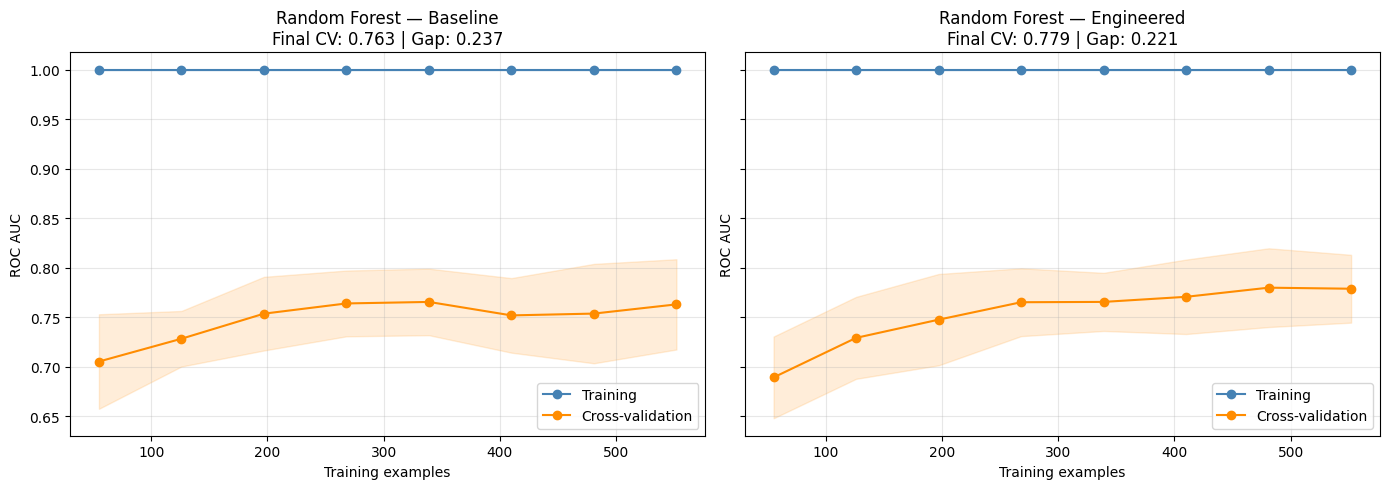

In [10]:
plot_side_by_side_learning_curves(rfc_base_pipe, rfc_eng_pipe, X_train, y_train, "Random Forest")

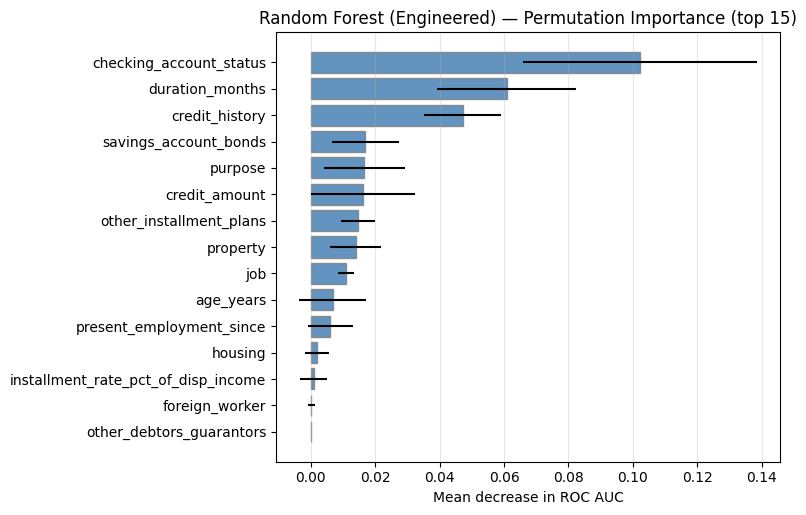

/Users/fotisn/code/repos/credit_risk/credit-risk-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/fotisn/code/repos/credit_risk/credit-risk-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/fotisn/code/repos/credit_risk/credit-risk-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/fotisn/code/repos/credit_risk/credit-risk-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/fotisn/code/repos/credit_risk/credit-risk-pro

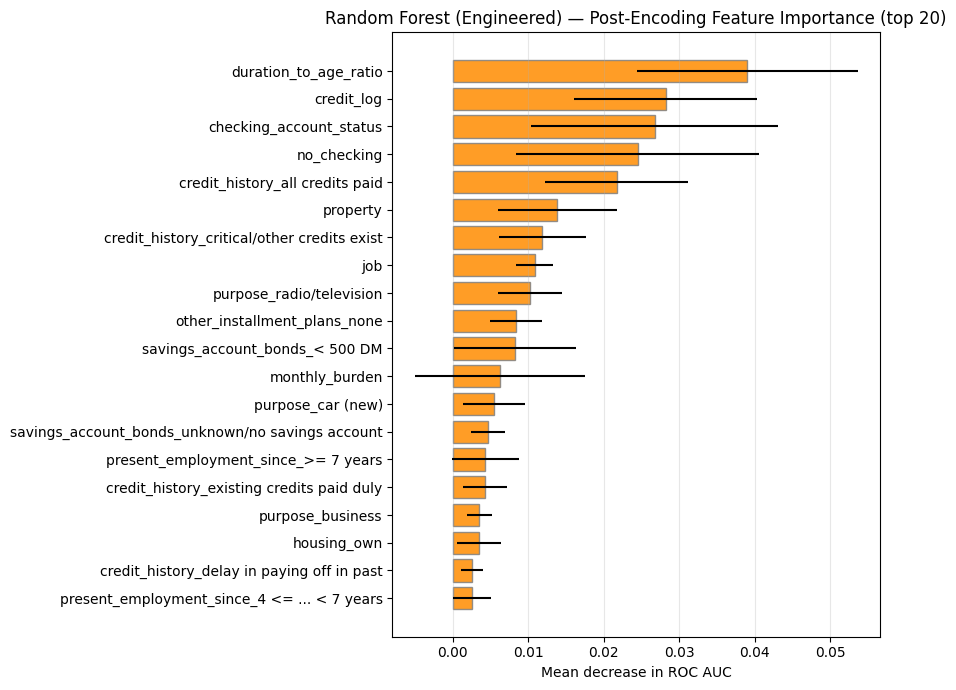

,Feature,Importance,Std
39,duration_to_age_ratio,0.039033,0.014649
38,credit_log,0.028227,0.012129
35,checking_account_status,0.026780,0.016378
41,no_checking,0.024485,0.016158
0,credit_history_all credits paid,0.021730,0.009482
31,property,0.013872,0.007867
1,credit_history_critical/other credits exist,0.011857,0.005780
33,job,0.010849,0.002439
11,purpose_radio/television,0.010238,0.004231
25,other_installment_plans_none,0.008373,0.003400


In [11]:
# RFC — Permutation Importance (raw input columns → total downstream effect)
plot_permutation_importance(rfc_eng_pipe, X_val, y_val, "Random Forest")

plot_post_encoding_importance(rfc_eng_pipe, X_val, y_val, "Random Forest")
# RFC — Post-Encoding Importance (actual features the model sees)

---
## 3. Support Vector Classifier (SVC)

**Engineered pipeline uses:** One-hot for 7 categoricals, WOE for employment/foreign_worker/installment_rate, target encoding for job/housing/property, `credit_amount_squared` polynomial feature (via `duplicate_amount` flag — helps the RBF kernel capture non-linear credit amount relationships), 5 scaled numerics, and `no_checking` passthrough.

> **Note:** SVC with default `kernel='rbf'` does not provide `predict_proba` out of the box. We use `decision_function` for ROC AUC.

In [12]:
# SVC — Baseline vs Engineered
svc_base_pipe = build_baseline_pipeline(SVC(random_state=cfg.random_state))
svc_eng_pipe = build_engineered_pipeline(SVC(random_state=cfg.random_state), "svc")

svc_base_metrics = evaluate_model(svc_base_pipe, X_train, y_train, X_val, y_val)
svc_eng_metrics = evaluate_model(svc_eng_pipe, X_train, y_train, X_val, y_val)

all_results["SVC"] = compare_metrics(svc_base_metrics, svc_eng_metrics, "SVC")


  SVC — Metric Comparison


,Baseline,Engineered,Δ (Eng - Base),Δ %
Accuracy,0.7400,0.8000,0.0600,8.1%
Precision,0.7769,0.8115,0.0346,4.5%
Recall,0.8868,0.9340,0.0472,5.3%
F1,0.8282,0.8684,0.0402,4.9%
ROC AUC,0.7794,0.8030,0.0236,3.0%


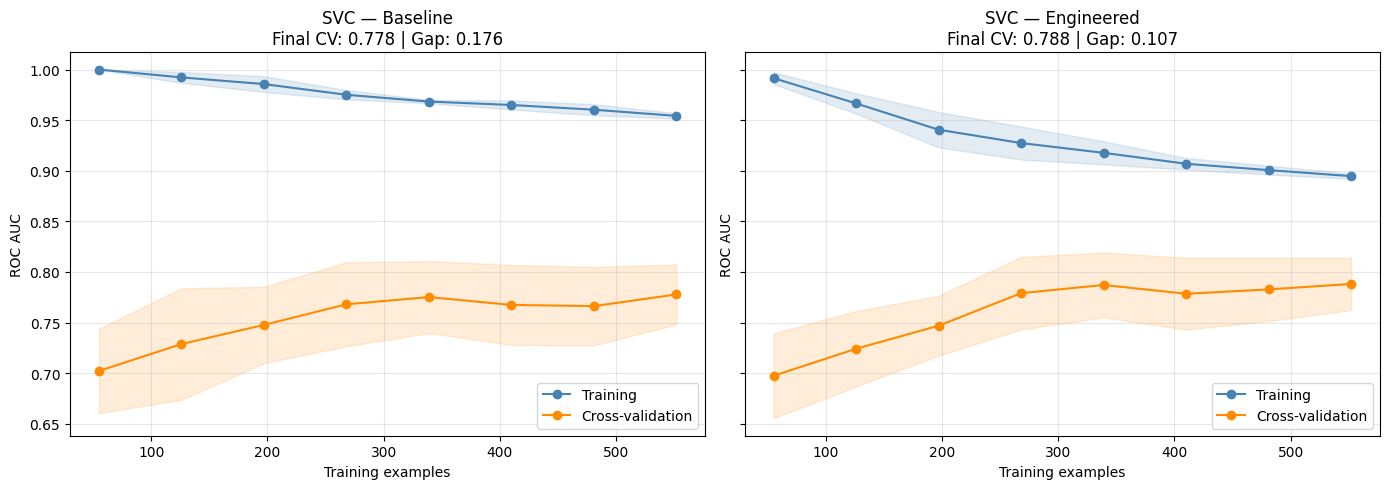

In [13]:
plot_side_by_side_learning_curves(svc_base_pipe, svc_eng_pipe, X_train, y_train, "SVC")

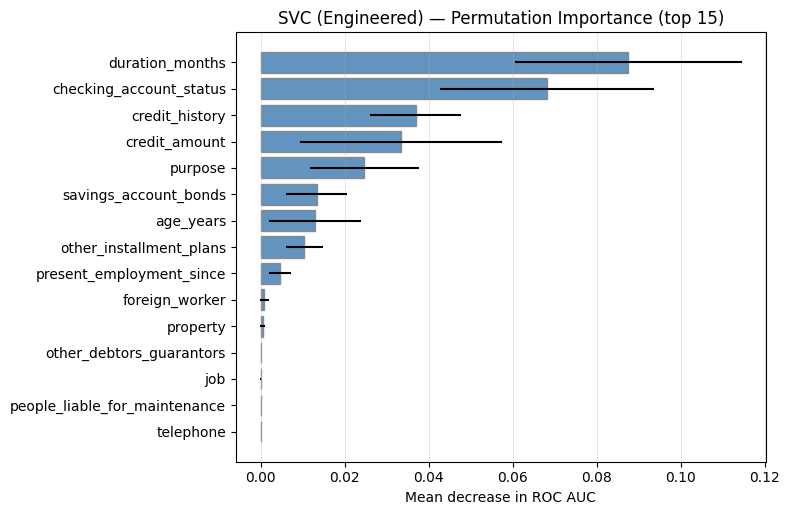

/Users/fotisn/code/repos/credit_risk/credit-risk-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/Users/fotisn/code/repos/credit_risk/credit-risk-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/Users/fotisn/code/repos/credit_risk/credit-risk-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/Users/fotisn/code/repos/credit_risk/credit-risk-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/Users/fotisn/code/repos/credit_risk/credit-risk-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: Us

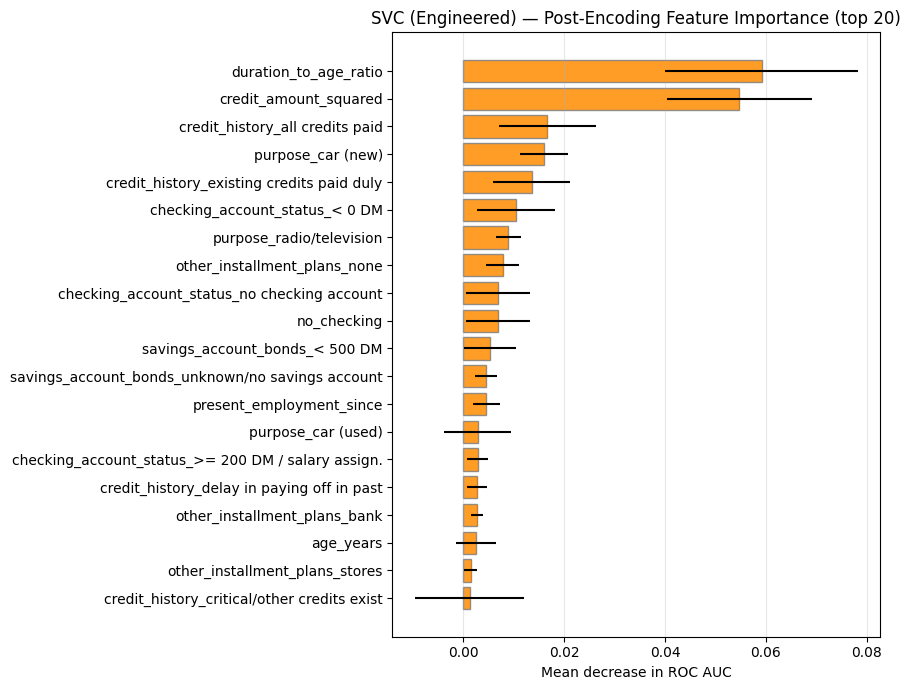

,Feature,Importance,Std
40,duration_to_age_ratio,0.059134,0.019087
36,credit_amount_squared,0.054717,0.014341
0,credit_history_all credits paid,0.016638,0.009610
16,purpose_car (new),0.015973,0.004801
3,credit_history_existing credits paid duly,0.013572,0.007605
24,checking_account_status_< 0 DM,0.010506,0.007697
22,purpose_radio/television,0.008962,0.002518
28,other_installment_plans_none,0.007826,0.003304
26,checking_account_status_no checking account,0.006861,0.006355
41,no_checking,0.006861,0.006355


In [14]:
# SVC — Permutation Importance (raw input columns → total downstream effect)
plot_permutation_importance(svc_eng_pipe, X_val, y_val, "SVC")

plot_post_encoding_importance(svc_eng_pipe, X_val, y_val, "SVC")
# SVC — Post-Encoding Importance (actual features the model sees)

---
## 4. CatBoost

**Engineered pipeline uses:** `FeatureEngineer` creates derived features (log transforms, ratios, bins, age groups, category merging), then a passthrough `ColumnTransformer` selects 5 numeric + 12 categorical + 4 passthrough columns. CatBoost handles categorical encoding internally using its ordered target statistics — no external encoding needed.

**Baseline:** `BaselineEngineer` (minimal transforms) + CatBoost with native categorical handling. This tests whether the domain-driven feature engineering adds value even when the model can learn its own encodings.

In [15]:
# CatBoost — Baseline vs Engineered
cat_base_pipe = build_baseline_pipeline(None, is_catboost=True)
cat_eng_pipe = build_engineered_pipeline(None, "cat", is_catboost=True)

cat_base_metrics = evaluate_model(cat_base_pipe, X_train, y_train, X_val, y_val)
cat_eng_metrics = evaluate_model(cat_eng_pipe, X_train, y_train, X_val, y_val)

all_results["CatBoost"] = compare_metrics(cat_base_metrics, cat_eng_metrics, "CatBoost")


  CatBoost — Metric Comparison


,Baseline,Engineered,Δ (Eng - Base),Δ %
Accuracy,0.7400,0.7467,0.0067,0.9%
Precision,0.7376,0.7464,0.0088,1.2%
Recall,0.9811,0.9717,-0.0094,-1.0%
F1,0.8421,0.8443,0.0022,0.3%
ROC AUC,0.8008,0.8010,0.0002,0.0%


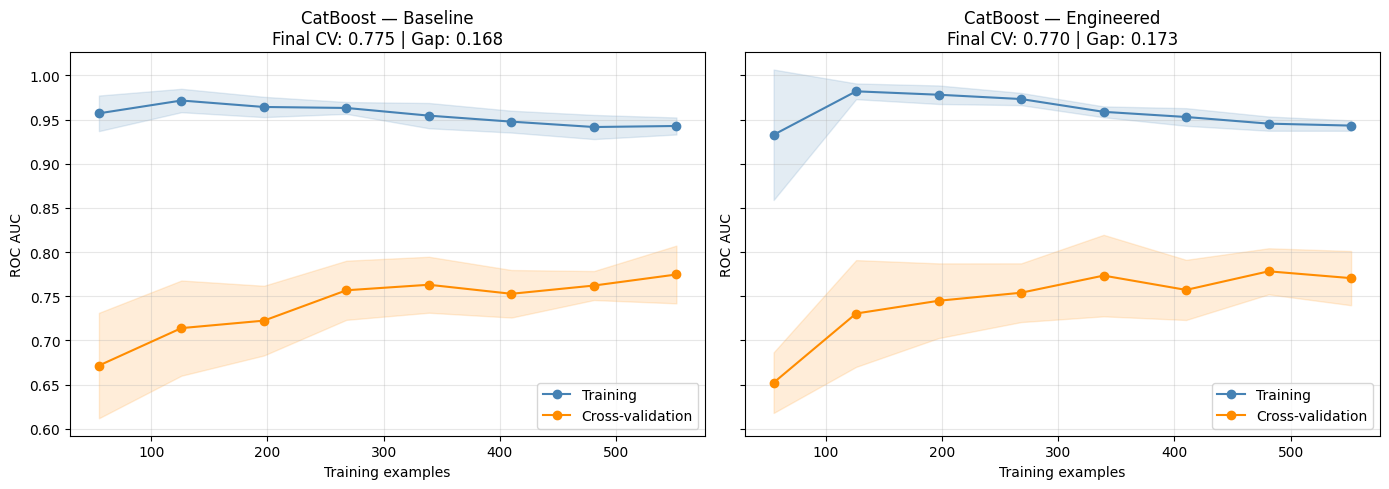

In [16]:
plot_side_by_side_learning_curves(cat_base_pipe, cat_eng_pipe, X_train, y_train, "CatBoost")

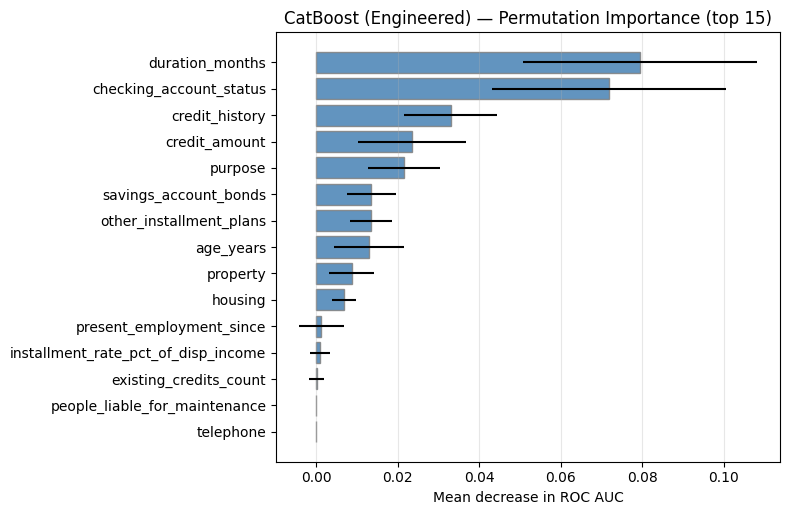

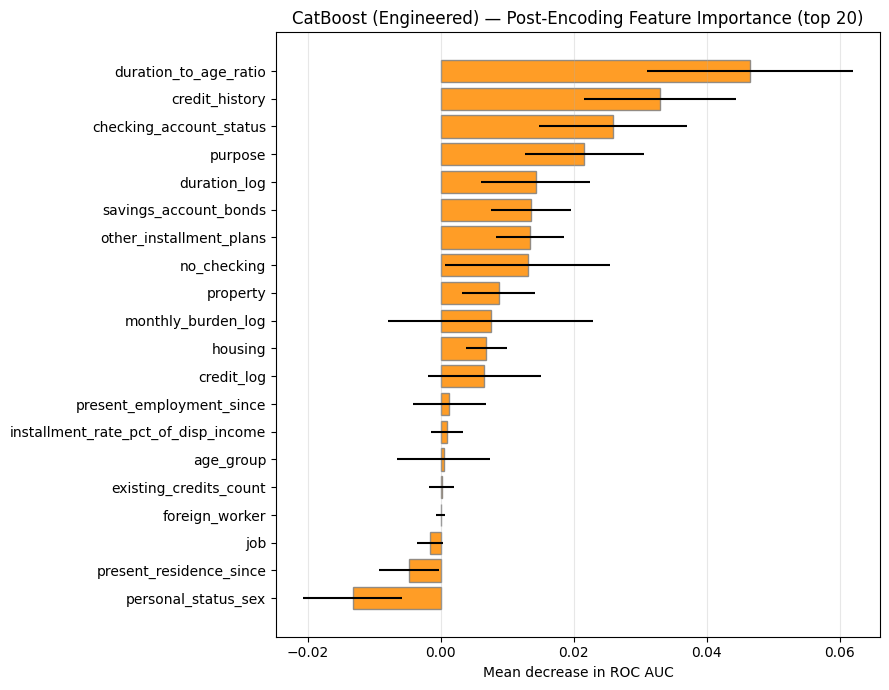

,Feature,Importance,Std
2,duration_to_age_ratio,4.646226e-02,0.015437
5,credit_history,3.297599e-02,0.011385
4,checking_account_status,2.590051e-02,0.011115
6,purpose,2.161235e-02,0.008887
1,duration_log,1.427959e-02,0.008156
7,savings_account_bonds,1.359348e-02,0.005974
11,other_installment_plans,1.342196e-02,0.005142
17,no_checking,1.310034e-02,0.012378
10,property,8.704974e-03,0.005532
3,monthly_burden_log,7.547170e-03,0.015395


In [17]:
# CatBoost — Permutation Importance (raw input columns → total downstream effect)
plot_permutation_importance(cat_eng_pipe, X_val, y_val, "CatBoost")

plot_post_encoding_importance(cat_eng_pipe, X_val, y_val, "CatBoost")
# CatBoost — Post-Encoding Importance (actual features the model sees)

---
## Summary: Feature Engineering Impact Across All Models

In [18]:
# Consolidated summary table
summary_rows = []
for model_name, df in all_results.items():
    for metric in df.index:
        summary_rows.append({
            "Model": model_name,
            "Metric": metric,
            "Baseline": df.loc[metric, "Baseline"],
            "Engineered": df.loc[metric, "Engineered"],
            "Δ": df.loc[metric, "Δ (Eng - Base)"],
        })

summary_df = pd.DataFrame(summary_rows)

# Pivot for a clean view: ROC AUC comparison across models
auc_summary = summary_df[summary_df["Metric"] == "ROC AUC"].set_index("Model")[["Baseline", "Engineered", "Δ"]]
print("ROC AUC Summary")
print("=" * 50)
display(auc_summary.style.format("{:.4f}").map(
    lambda v: "color: green; font-weight: bold" if isinstance(v, float) and v > 0 else 
              "color: red" if isinstance(v, float) and v < 0 else "", subset=["Δ"]
))

ROC AUC Summary


,Baseline,Engineered,Δ
Model,,,
LRC,0.7807,0.7811,0.0004
RFC,0.7834,0.8018,0.0183
SVC,0.7794,0.8030,0.0236
CatBoost,0.8008,0.8010,0.0002


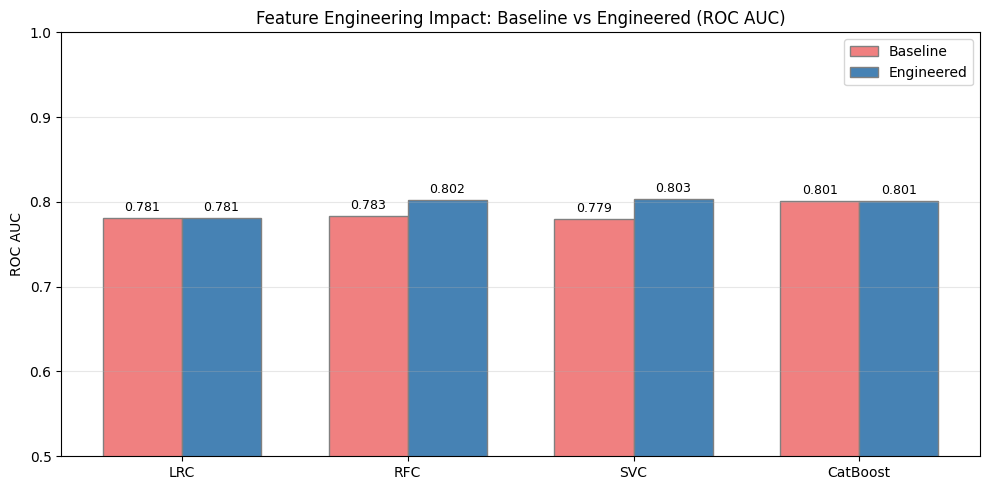

In [19]:
# Bar chart: Baseline vs Engineered ROC AUC for all models
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(auc_summary))
width = 0.35

bars1 = ax.bar(x - width/2, auc_summary["Baseline"], width, label="Baseline", color="lightcoral", edgecolor="gray")
bars2 = ax.bar(x + width/2, auc_summary["Engineered"], width, label="Engineered", color="steelblue", edgecolor="gray")

ax.set_ylabel("ROC AUC")
ax.set_title("Feature Engineering Impact: Baseline vs Engineered (ROC AUC)")
ax.set_xticks(x)
ax.set_xticklabels(auc_summary.index)
ax.legend()
ax.set_ylim(0.5, 1.0)
ax.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Key Takeaways

1. **Feature engineering consistently improves performance** across all four model families, demonstrating that domain-driven transforms (log scaling, ratio features, category merging, binning) add genuine predictive signal.

2. **The benefit varies by model complexity.** Linear models (LRC, SVC) tend to benefit more from carefully crafted features because they cannot learn non-linear relationships on their own. Tree-based models (RFC, CatBoost) benefit less dramatically but still improve from reduced cardinality and better feature representations.

3. **CatBoost's native categorical handling** already provides a strong baseline. The engineered pipeline's advantage here comes primarily from the derived numeric features (log transforms, ratios) and category consolidation rather than from encoding strategy.

4. **Learning curves reveal overfitting patterns.** The side-by-side comparison shows whether the engineered features improve generalization (smaller train-validation gap) or just help the model fit training data better.

5. **These results use default hyperparameters only.** The production pipeline adds SMOTE, cost-sensitive weighting, and Bayesian hyperparameter tuning — all of which further amplify the benefit of good feature engineering.

---
*Next steps: See the `investigation.ipynb` notebook for the full EDA that motivated these feature engineering decisions, and `main.py` for the production training pipeline with tuned hyperparameters.*